# Feature Engineering Notebook

Centralized notebook for the NextBuy feature-engineering pipeline: generation, inspection, and modeling readiness.

## 1) Setup and Imports
This notebook uses the existing project module `feature_engineering.py`.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from feature_engineering import FeatureEngineer

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)

MASTER_PATH = 'master_dataset.csv'
SAMPLE_OUTPUT_PATH = 'features_dataset_sample.csv'
FULL_OUTPUT_PATH = 'features_dataset.csv'

print('Working directory:', os.getcwd())
print('Master dataset exists:', os.path.exists(MASTER_PATH))

Working directory: /home/milan/Documents/B-DAT-201-LYN-2-1-nextbuy-4
Master dataset exists: True


## 2) Load Data
You can run in sample mode first for faster iteration.

In [ ]:
df_master = pd.read_csv(MASTER_PATH)
print('Rows:', f"{len(df_master):,}")
print('Columns:', len(df_master.columns))
display(df_master.head(3))

Rows: 13,691,080
Columns: 14


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1.0,1.0,202279,3,5,9,8,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2.0,1.0,202279,3,5,9,8,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3.0,0.0,202279,3,5,9,8,Garlic Powder,104,13,spices seasonings,pantry


## 3) Optional: Sample Subset for Faster Runs

In [ ]:
USE_SAMPLE = True
SAMPLE_USERS = 1000

if USE_SAMPLE:
    sample_user_ids = df_master['user_id'].dropna().unique()[:SAMPLE_USERS]
    df_input = df_master[df_master['user_id'].isin(sample_user_ids)].copy()
    output_path = SAMPLE_OUTPUT_PATH
else:
    df_input = df_master.copy()
    output_path = FULL_OUTPUT_PATH

print('Using sample mode:', USE_SAMPLE)
print('Input rows:', f"{len(df_input):,}")
print('Unique users:', f"{df_input['user_id'].nunique():,}")

Using sample mode: True
Input rows: 145,768
Unique users: 1,000


## 4) Run Feature Engineering
Creates user history, product popularity, recency, and cart-position features.

In [ ]:
engineer = FeatureEngineer(df_input)
df_features = engineer.create_all_features(verbose=True)
engineer.get_feature_summary(df_features)
engineer.save_features(df_features, output_path)

print('Saved to:', output_path)
print('Final shape:', df_features.shape)

Creating user history features...
Creating product popularity features...
Creating user-product interaction features...
Creating recency features...

FEATURE ENGINEERING SUMMARY
Total new features created: 48
  • User history features: 17
  • Product popularity features: 14
  • User-product interaction features: 14
  • Recency features: 3

Dataset shape: (145768, 62)
Memory usage: 92.68 MB

✓ Features saved to features_dataset_sample.csv
Saved to: features_dataset_sample.csv
Final shape: (145768, 62)


## 5) Inspect Engineered Features

In [ ]:
original_cols = [
    'order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
    'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order',
    'product_name', 'aisle_id', 'department_id', 'aisle', 'department'
]

new_features = [c for c in df_features.columns if c not in original_cols]
user_features = [c for c in new_features if c.startswith('user_')]
product_features = [c for c in new_features if c.startswith('product_')]
up_features = [c for c in new_features if c.startswith('up_')]
other_features = [c for c in new_features if c not in user_features + product_features + up_features]

print('New features:', len(new_features))
print('User features:', len(user_features))
print('Product features:', len(product_features))
print('User-product features:', len(up_features))
print('Other features:', len(other_features))

display(df_features[new_features[:20]].head(3))

New features: 48
User features: 17
Product features: 14
User-product features: 14
Other features: 3


,user_total_orders,user_unique_products,user_avg_basket_size,user_total_reorders,user_max_basket_size,user_min_basket_size,user_std_basket_size,user_avg_days_between_orders,user_std_days_between_orders,user_reorder_rate,user_order_frequency,user_product_diversity,user_preferred_dow,user_preferred_hour,user_max_order_number,user_unique_departments,user_unique_aisles,product_orders_count,product_users_count,product_reorders_count
0,4,32,6.787234,23.0,17,9,3.593976,10.25,10.012492,5.75,0.355556,8.0,5,9,7,8,20,96,27,80.0
1,4,32,6.787234,23.0,17,9,3.593976,10.25,10.012492,5.75,0.355556,8.0,5,9,7,8,20,275,95,206.0
2,4,32,6.787234,23.0,17,9,3.593976,10.25,10.012492,5.75,0.355556,8.0,5,9,7,8,20,31,26,7.0


## 6) Quick Modeling Readiness Check
Trains a lightweight baseline model to validate signal quality.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

df_model = df_features.copy()
numeric_cols = df_model.select_dtypes(include='number').columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(0)

exclude_cols = ['order_id', 'product_id', 'user_id']
candidate_cols = [
    c for c in df_model.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_model[c])
]

X = df_model[candidate_cols].astype(float)
y = df_model['reordered'].fillna(0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=80,
    max_depth=10,
    min_samples_split=20,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('ROC AUC:', round(roc_auc_score(y_test, y_prob), 4))
print(classification_report(y_test, y_pred, target_names=['Not Reordered', 'Reordered']))

ROC AUC: 1.0
               precision    recall  f1-score   support

Not Reordered       1.00      1.00      1.00      9537
    Reordered       1.00      1.00      1.00     19617

     accuracy                           1.00     29154
    macro avg       1.00      1.00      1.00     29154
 weighted avg       1.00      1.00      1.00     29154



## 7) Feature Importance

,feature,importance
1,reordered,0.396213
47,up_reorder_rate,0.171266
40,up_reorder_count,0.139187
48,up_product_tenure,0.051156
39,up_order_count,0.039045
2,order_number,0.034411
50,up_consistency_score,0.031171
42,up_cart_std,0.030872
55,order_recency_score,0.022537
28,product_reorder_rate,0.013636


/tmp/ipykernel_12545/3538769932.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')


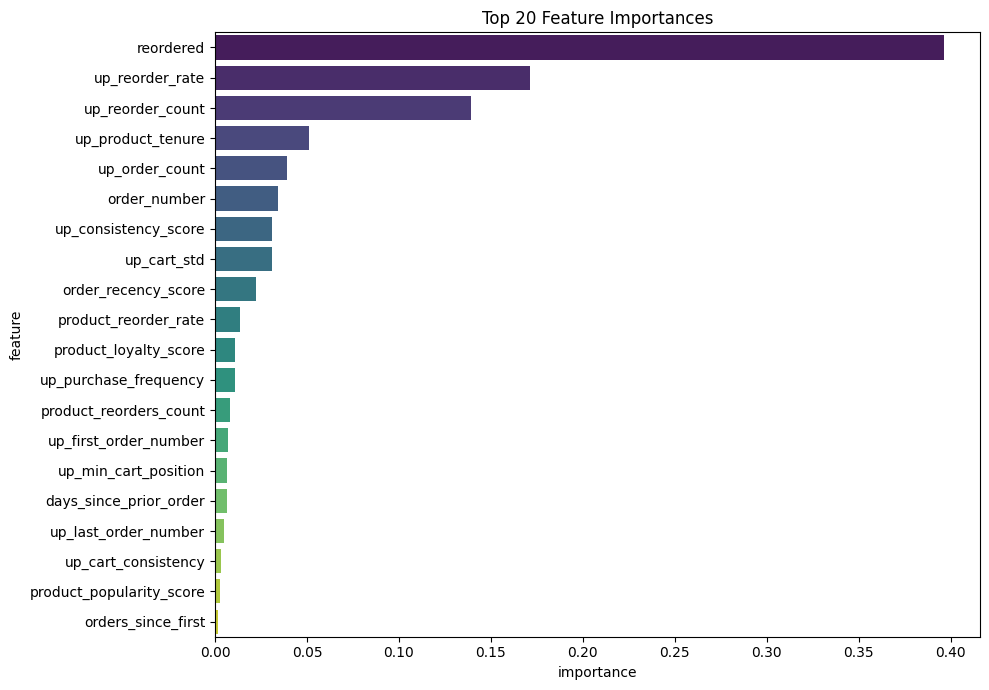

In [ ]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(20), x='importance', y='feature', palette='viridis')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

## 8) Next Steps
- Switch `USE_SAMPLE = False` to run full production feature generation.
- Persist train/test splits for reproducibility.
- Evaluate gradient boosting models (XGBoost/LightGBM) for higher lift.